# TASK 2 : Exploratory Data Analysis(EDA)

## Step 1 : Reload the dataset

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco_Customer_Churn_Dataset .csv")

## Step 2 : Perform only cleaning steps

In [4]:
# Replace Blank Spaces
df['TotalCharges'] = df['TotalCharges'].replace(" ",np.nan)

# Convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Drop missing values
df.dropna(inplace=True)

## Step 3 : Check Dataset Overview

In [5]:
print("Shape:",df.shape)

df.head()

Shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 4 : Calculate overall churn rate

In [7]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


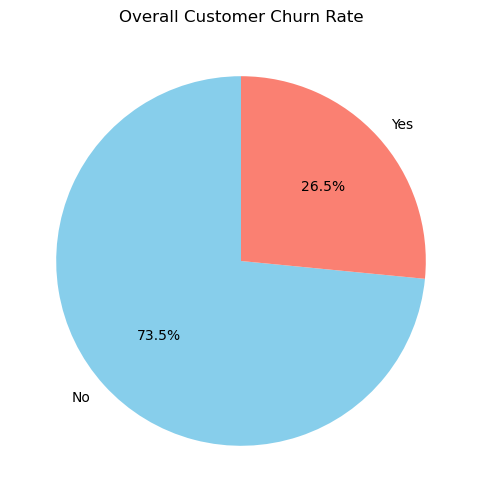

In [10]:
plt.figure(figsize=(6,6))

plt.pie(
    df["Churn"].value_counts(),
    labels=df["Churn"].value_counts().index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue","salmon"]
)

plt.title("Overall Customer Churn Rate")

plt.show()

### Business Insight

##### Approximately 26.6% of customers have churned, while 73.4% remain active. 
##### This indicates that nearly one in four customers leaves the company, suggesting a significant opportunity to improve customer retention.

## Step 5 : Churn Count

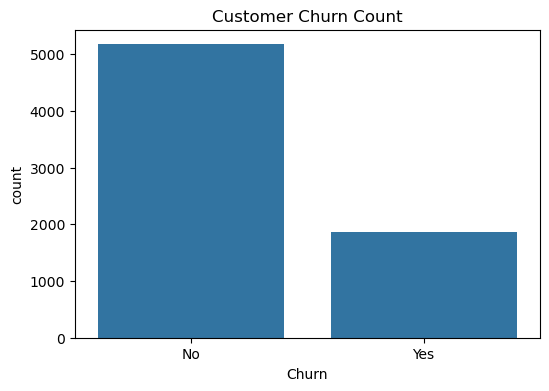

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Count")

plt.show()

### Businesss Insight :-

##### The number of customers who stayed with the company is substantially higher than those who churned. 
##### However, the churned customer count is still significant enough to warrant further investigation into the factors driving customer attrition.

## Step 6 : Gender Distribution

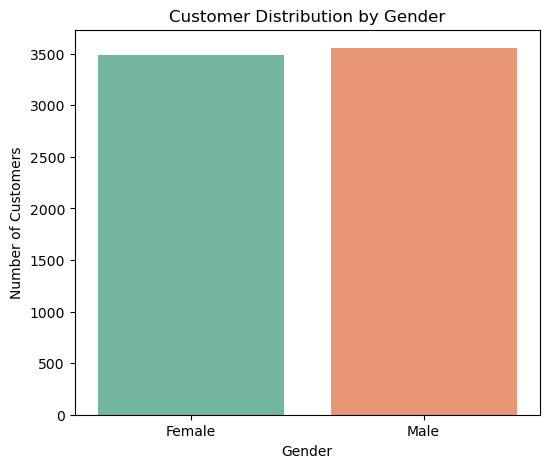

In [58]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="gender",
    hue='gender',
    data=df,
    palette="Set2"
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight
#### The customer base is almost equally divided between male and female customers, indicating a balanced gender distribution.

## Step 7 : Gender vs Churn

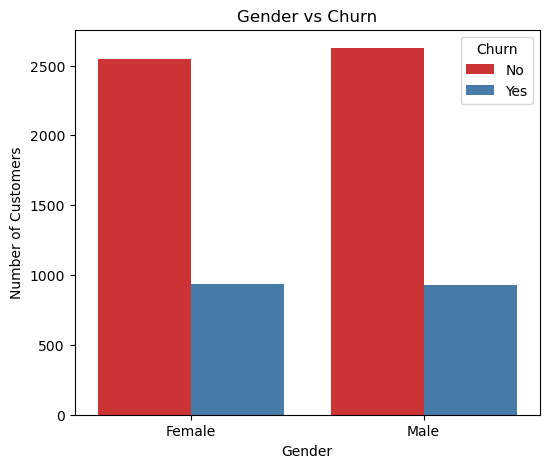

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="gender",
    hue="Churn",
    data=df,
    palette="Set1"
)

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Calculate Churn Percentage

In [15]:
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)*100

gender_churn

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


### Business Insight
##### Both genders exhibit nearly identical churn rates, suggesting that gender has little influence on customer churn.

## Step 8 : Senior Citizen Analysis

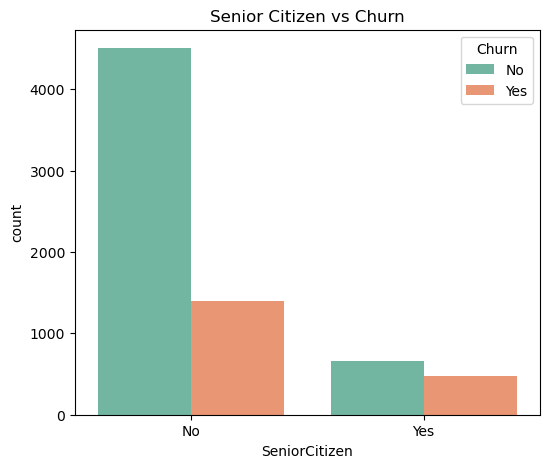

In [18]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="SeniorCitizen",
    hue="Churn",
    data=df,
    palette="Set2"
)

plt.title("Senior Citizen vs Churn")

plt.show()

### Churn Percentage

In [19]:
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
)*100

senior_churn

Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


### Business Insight
##### Senior citizens have a noticeably higher churn rate than non-senior customers.

## Step 9: Partner Analysis

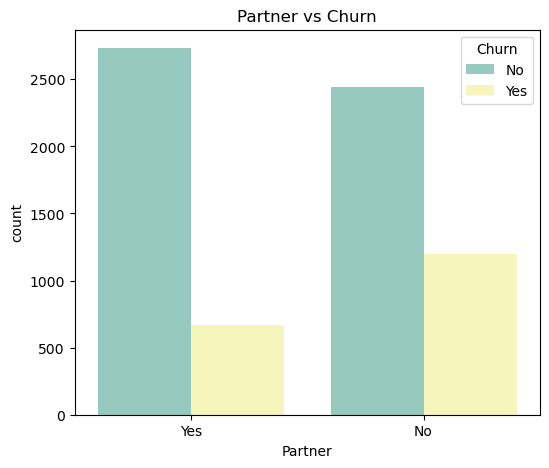

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Partner",
    hue="Churn",
    data=df,
    palette="Set3"
)

plt.title("Partner vs Churn")

plt.show()

### Churn Percentage

In [21]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
)*100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


### Business Insight
##### Customers without partners tend to churn more frequently than customers who have partners.

## Step 10 : Dependent Analysis

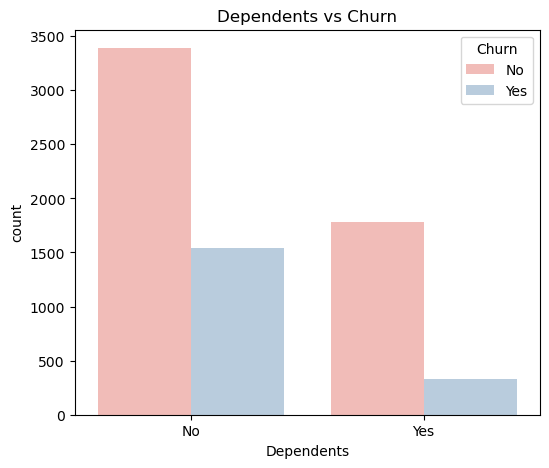

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Dependents",
    hue="Churn",
    data=df,
    palette="Pastel1"
)

plt.title("Dependents vs Churn")

plt.show()

### Churn Percentage

In [24]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize='index'
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


### Business Insight
##### Customers with dependents generally have lower churn rates, indicating stronger customer loyalty.

## Step 11 : Contract Type Analysis

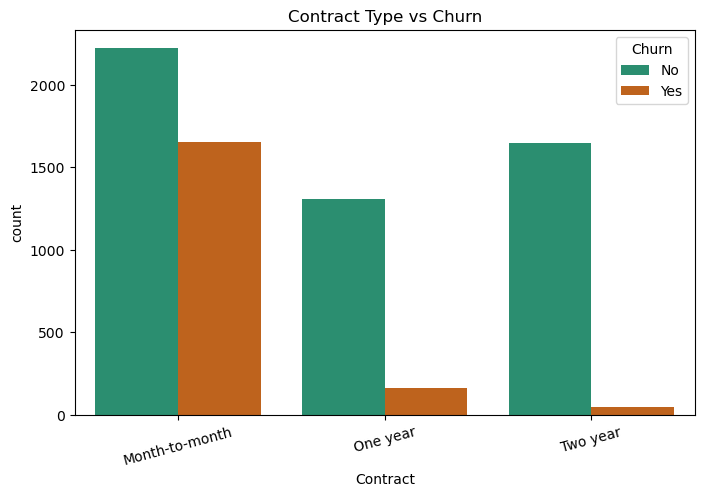

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="Dark2"
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

### Churn Percentage

In [28]:
contracts_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
)*100

contracts_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Business Insight
##### Customers with month-to-month contracts have the highest churn rate. 
##### Longer-term contracts (one-year and two-year) are associated with significantly better customer retention.

## Step 12 : Payment Method Analysis

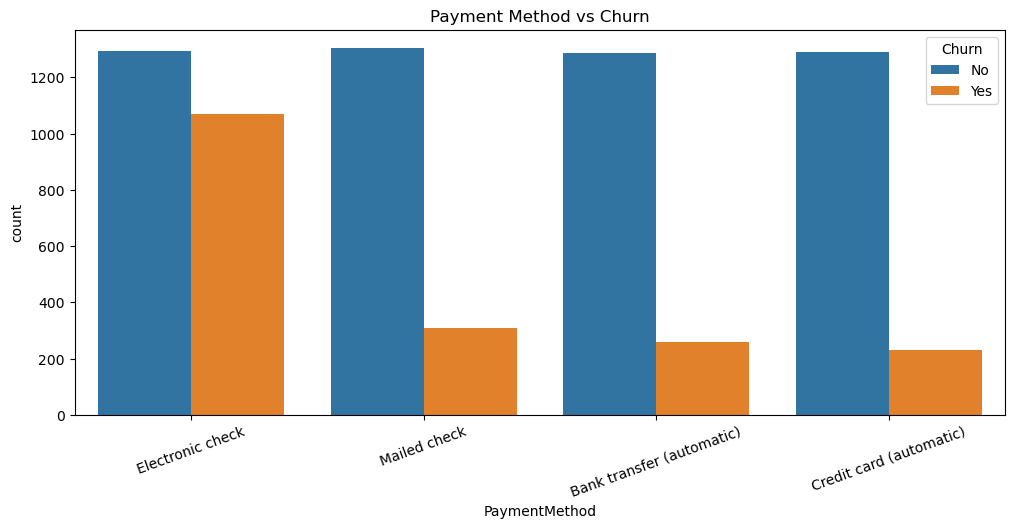

In [29]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df,
    palette="tab10"
)

plt.xticks(rotation=20)

plt.title("Payment Method vs Churn")

plt.show()

### Churn Percentage

In [38]:
Payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100

Payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


### Business Insight
##### Customers paying through electronic checks have the highest churn rate, while automatic payment methods are associated with better retention.

## Step 13 : Internet Service Analysis

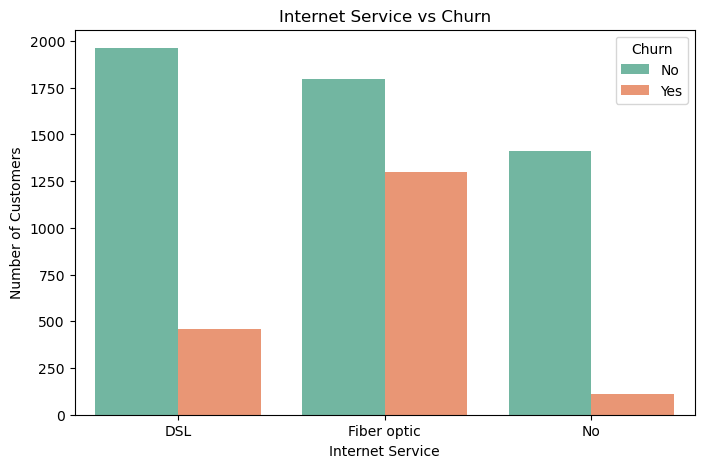

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df,
    palette="Set2"
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Churn Percentage

In [37]:
Internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
)*100

Internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


### Business Insight
##### Customers using Fiber Optic internet have the highest churn rate compared to DSL and customers with no internet service. This may indicate issues related to pricing, service quality, or customer expectations.

## Step 14 : Tenure Distribution

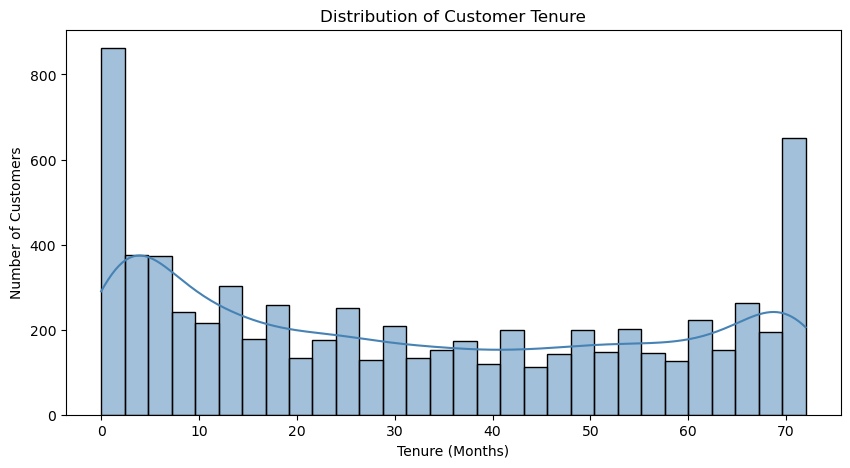

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Tenure vs Churn

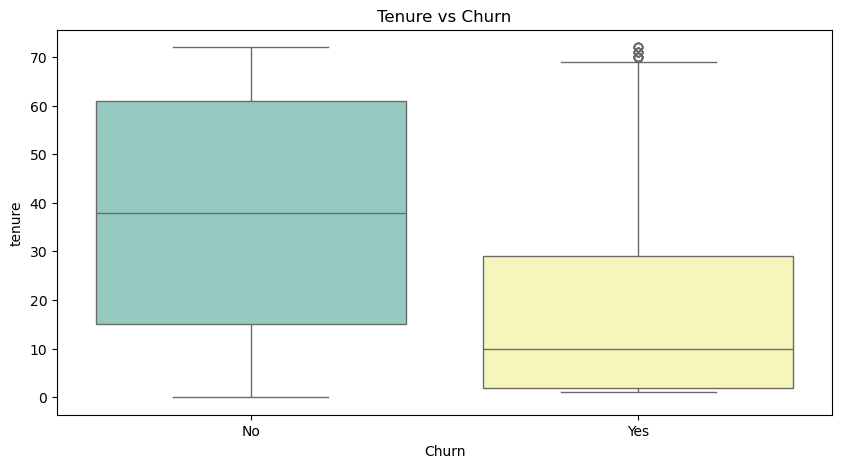

In [62]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    hue='Churn',
    data=df,
    palette="Set3"
)

plt.title("Tenure vs Churn")

plt.show()

### Business Insight
##### Customers with shorter tenure are much more likely to churn, while long-term customers tend to remain loyal. 
##### This suggests that retention efforts should focus on customers during their initial months.

# Step 15 : Monthly Charges Analysis

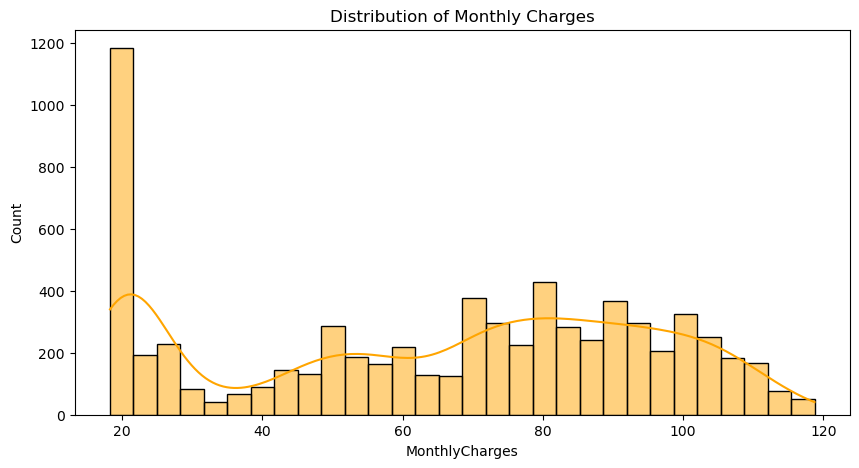

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Monthly Charges")

plt.show()

### Monthly Charges vs Churn

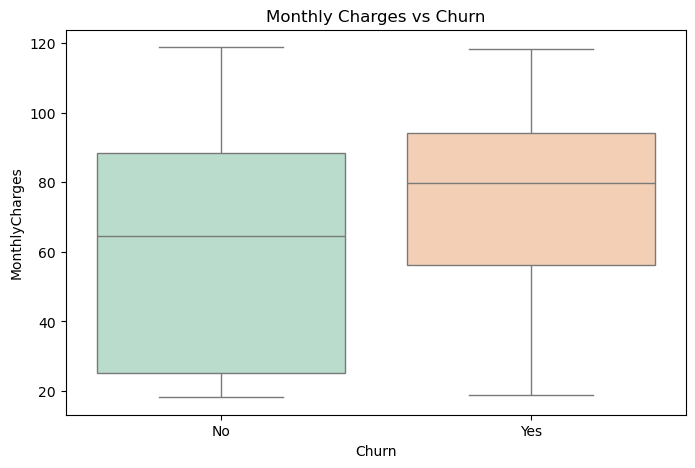

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    hue='Churn',
    y="MonthlyCharges",
    data=df,
    palette="Pastel2"
)

plt.title("Monthly Charges vs Churn")

plt.show()

### Business Insight
##### Customers who churn generally pay higher monthly charges than those who remain. This indicates that pricing may influence customer decisions.

## Step 16 : Total Charges Analysis

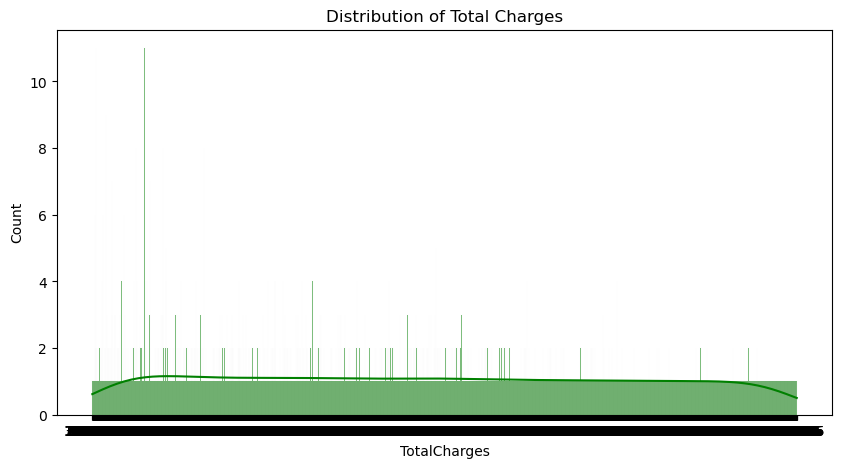

In [51]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Total Charges")

plt.show()

### Total Charges vs Churn

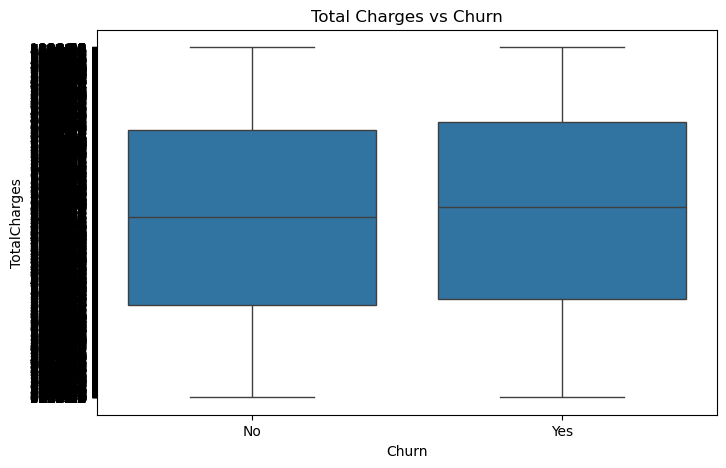

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="TotalCharges",
    data=df,
    #palette="Set1"
)

plt.title("Total Charges vs Churn")

plt.show()

### Business Insight
##### Customers with lower total charges tend to churn more because they are often newer customers with shorter tenures. Long-term customers accumulate higher total charges and are generally more loyal.

## Step 17 : Correlation Heatmap

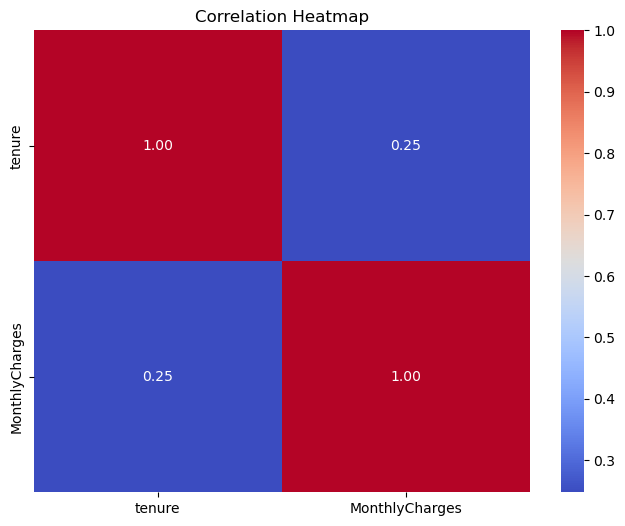

In [54]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight
##### The heatmap reveals that tenure and TotalCharges are strongly positively correlated, which is expected because customers who stay longer accumulate higher total charges. Monthly charges have a weaker relationship with tenure.

## Step 18 : Final Business Insight

## Key Findings
#### 1. Approximately 26.6% of customers have churned.
#### 2. Gender has minimal impact on customer churn.
#### 3. Senior citizens show a higher likelihood of churning.
#### 4. Customers without partners or dependents are more likely to leave.
#### 5. Month-to-month contracts have the highest churn rate.
#### 6. Electronic check users experience higher churn than customers using automatic payment methods.
#### 7. Fiber Optic internet users have the highest churn rate.
#### 8. Customers with shorter tenure are more likely to churn.
#### 9. Higher monthly charges are associated with increased churn.
#### 10. Long-term customers with higher total charges are generally more loyal.

## Step 19 : Business Recommendations

#### i. Encourage customers to switch from month-to-month to longer-term contracts by offering discounts or loyalty benefits.
#### ii. Launch retention campaigns targeting new customers during their first six months.
#### iii. Review pricing and service quality for Fiber Optic plans.
#### iv. Promote automatic payment methods through incentives to improve retention.
#### v. Identify customers with high monthly charges and offer personalized discounts or upgraded plans.
#### vi. Develop special retention programs for senior citizens and other high-risk customer segments.

## EDA Summary

The exploratory analysis revealed several important factors associated with customer churn. Customers on month-to-month contracts, those using Fiber Optic internet, electronic check payment methods, and customers with shorter tenure exhibited higher churn rates. Additionally, higher monthly charges were associated with increased churn. These findings suggest that improving customer retention should focus on early customer engagement, contract upgrades, pricing optimization, and targeted retention strategies for high-risk customer groups.